## Correlation matrix

In [2]:
import pandas as pd

In [3]:
df=pd.read_csv("cleaned_and_updated_apple_products_pricing.csv")

                   Launch_Price_USD  Launch_Price_INR  Current_Price_USD
Launch_Price_USD           1.000000          1.000000           0.947179
Launch_Price_INR           1.000000          1.000000           0.947179
Current_Price_USD          0.947179          0.947179           1.000000


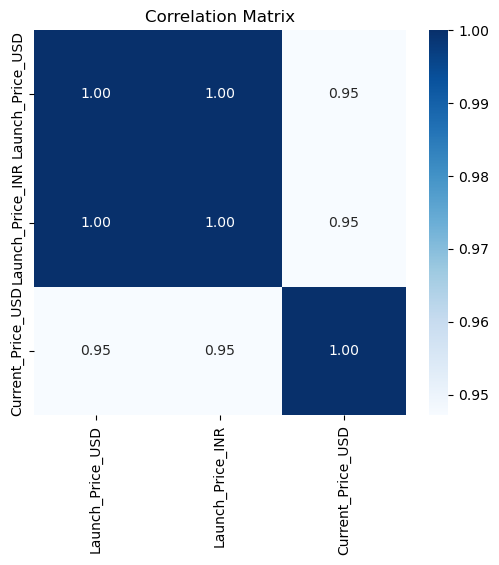

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

corr = df[['Launch_Price_USD',
           'Launch_Price_INR',
           'Current_Price_USD']].corr()

print(corr)

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='Blues', fmt='.2f')
plt.title("Correlation Matrix")
plt.show()

### Interpretation :
- Launch Price USD and Launch Price INR have a very strong positive correlation (≈1.00) because INR is converted from USD.
- Current Price USD is also strongly positively correlated with Launch Price USD, meaning expensive products generally remain more expensive over time.

## Variance Analysis

#### A. Product category

In [5]:
variance_category = df.groupby('Product_Category')['Current_Price_USD'].var()
print(variance_category)

Product_Category
Mac       232780.695291
Watch      29361.306055
iPad       84304.823710
iPhone     42216.890321
Name: Current_Price_USD, dtype: float64


#### B. Stock status

In [6]:
variance_stock = df.groupby('Stock_Status')['Current_Price_USD'].var()
print(variance_stock)

Stock_Status
In Stock        215940.857654
Low Stock       197604.206840
Out of Stock    196842.004904
Name: Current_Price_USD, dtype: float64


### Interpretation
- Category with higher variance have a wider range of prices
- Category with lower variance have more consistent pricing
- Diifferent stock statusus (In stock, Out of stock, Limited stock) may shoq different levels of price variation

### Statistical validation of Main Hypothesis
#### Main Hypothesis
- H₀ (Null Hypothesis): Product category has no significant effect on current product price.
- H₁ (Alternative Hypothesis): Product category significantly affects current product price.

In [7]:
from scipy.stats import f_oneway

groups = [
    group['Current_Price_USD'].dropna()
    for name, group in df.groupby('Product_Category')
]

f_stat, p_value = f_oneway(*groups)

print("F-statistic:", f_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("Reject H0")
    print("Product category significantly affects current price.")
else:
    print("Fail to reject H0")
    print("No significant difference among product categories.")

F-statistic: 36181.14563609675
P-value: 0.0
Reject H0
Product category significantly affects current price.


#### Interpretation
- If p-value < 0.05, the differences in current prices across product categories are statistically significant.
- If p-value ≥ 0.05, there is no statistically significant difference between categories.

### Limitations
- The analysis is based only on the available Apple products dataset
- Market conditions and promotional discounts may affect product prices over time
- Correlation does not imply a cause-and-effect relationship
- Other factors such as product condition, ratings, storage capacity, and sale events were not included in this analysis.
  